# Assignment 2:  Image Classification

First we import the library that we are going to use and see if the GPU is available here.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50
import itertools
import zipfile

# Verifying GPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  1


We load the datasets

In [ ]:
images = np.load("/content/drive/MyDrive/images.npy")
labels = pd.read_csv("/content/drive/MyDrive/Labels.csv")

In [ ]:
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print(labels.head())

Images shape: (4750, 128, 128, 3)
Labels shape: (4750, 1)
                       Label
0  Small-flowered Cranesbill
1  Small-flowered Cranesbill
2  Small-flowered Cranesbill
3  Small-flowered Cranesbill
4  Small-flowered Cranesbill


Analyse the dataset and the distribution of classes to see if there is class imbalance.

                        class  count
6            Loose Silky-bent    654
3            Common Chickweed    611
8           Scentless Mayweed    516
10  Small-flowered Cranesbill    496
5                     Fat Hen    475
1                    Charlock    390
11                 Sugar beet    385
2                    Cleavers    287
0                 Black-grass    263
9             Shepherds Purse    231
7                       Maize    221
4                Common wheat    221


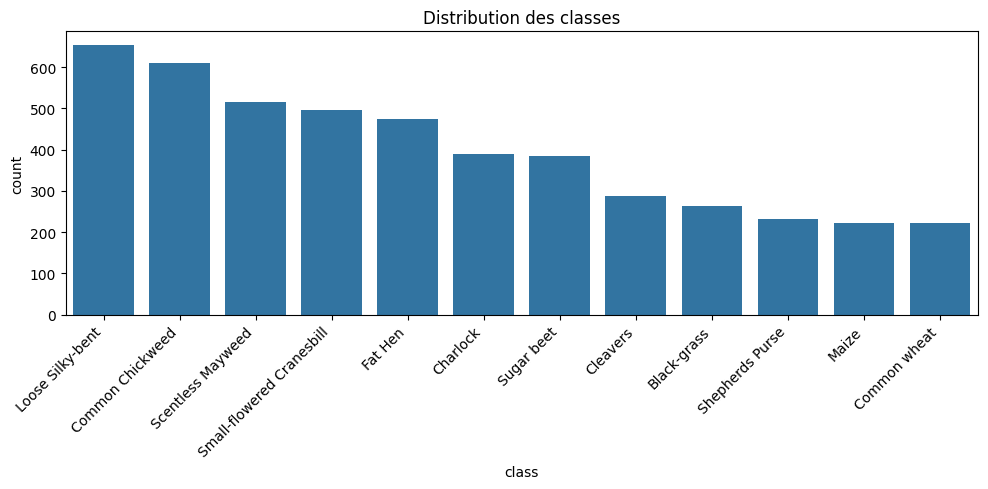

In [ ]:
# Show the distribution of the classes
labels1 = labels.iloc[:,0].values  # use the first column
unique, counts = np.unique(labels1, return_counts=True)
dist_df = pd.DataFrame({'class': unique, 'count': counts}).sort_values('count', ascending=False)
print(dist_df)

plt.figure(figsize=(10,5))
sns.barplot(data=dist_df, x='class', y='count')
plt.xticks(rotation=45, ha='right')
plt.title("Distribution des classes")
plt.tight_layout()
plt.show()

Here, we can see that there is some class imbalance.

We visualise the images to see if there is problems

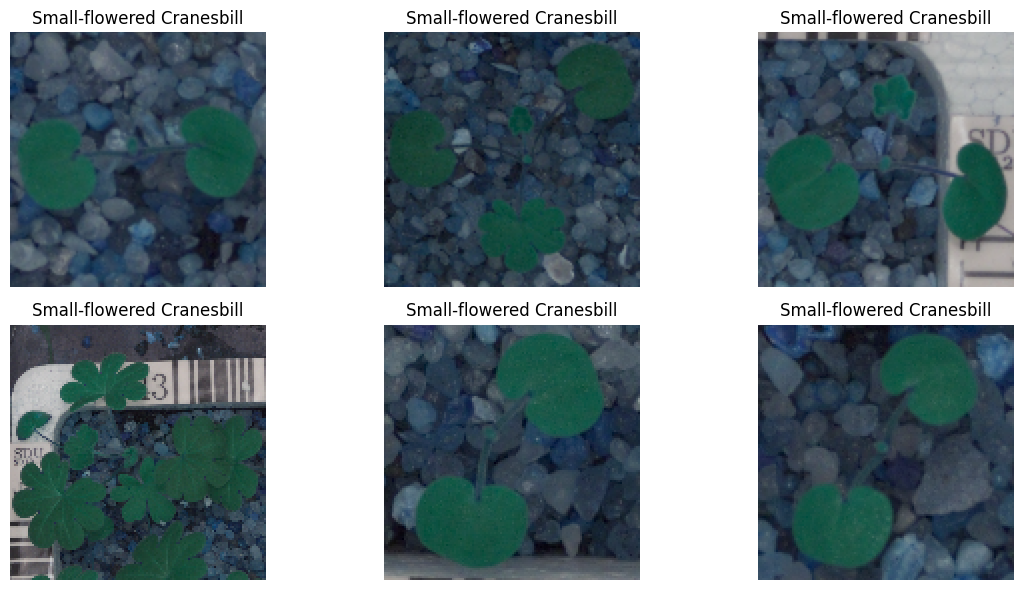

In [ ]:
import matplotlib.pyplot as plt

# number of images
n = 6

plt.figure(figsize=(12, 6))

for i in range(n):
    plt.subplot(2, 3, i + 1)  # 2 row × 3 columns = 6 cases
    plt.imshow(images[i].astype('uint8'))  # convert on image
    plt.title(labels.iloc[i, 0])  # show the class name (colonne du CSV)
    plt.axis('off')

plt.tight_layout()
plt.show()

Here I first tried to put the images in grayscale to have less data and help the model to be faster but this was bringing the accuracy of my model really low because the images where really bad after the convertion.

In [ ]:
# import cv2

# gray_images = []
# for img in images:
#     gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)   # conversion
#     gray = cv2.resize(gray, (64, 64))              # redimension
#     gray = gray.astype("float32") / 255.0         # normalisation
#     gray_images.append(gray)

# gray_images = np.array(gray_images).reshape(-1, 64, 64, 1)


Look if it's now in grayscale

In [ ]:
# plt.imshow(gray_images[0].squeeze(), cmap='gray')
# plt.title("Checking grayscale preprocessing")
# plt.show()


# Data Processing
We resizes the images to 64x64 encode the labels and split the data.

In [ ]:
import numpy as np
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Resize images from 128x128 to 64x64
images_resized = np.array([cv2.resize(img, (64, 64)) for img in images])
images_resized = images_resized / 255.0  # Normalize

# Convert labels DataFrame to 1D array
labels_array = labels.values.flatten()  # ou labels['label_column_name'].values

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels_array)
labels_categorical = to_categorical(labels_encoded, num_classes=12)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    images_resized, labels_categorical, test_size=0.2, random_state=42, stratify=labels_categorical
)


# Model 1:  Basic CNN Model


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       204,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,212 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,616 (920.38 KB)

 Trainable params: 235,616 (920.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.1508 - loss: 2.3987 - val_accuracy: 0.3921 - val_loss: 1.7733
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4007 - loss: 1.6682 - val_accuracy: 0.3895 - val_loss: 1.7994
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5030 - loss: 1.3977 - val_accuracy: 0.6026 - val_loss: 1.1406
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6260 - loss: 1.0892 - val_accuracy: 0.6447 - val_loss: 1.0428
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7096 - loss: 0.8854 - val_accuracy: 0.6868 - val_loss: 0.9002
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7342 - loss: 0.7822 - val_accuracy: 0.7000 - val_loss: 0.9401
Epoch 7/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7591 - loss: 0.7360 - val_accuracy: 0.7079 - val_loss: 0.8359
Epoch 8/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8057 - loss: 0.5768 - val_accuracy: 

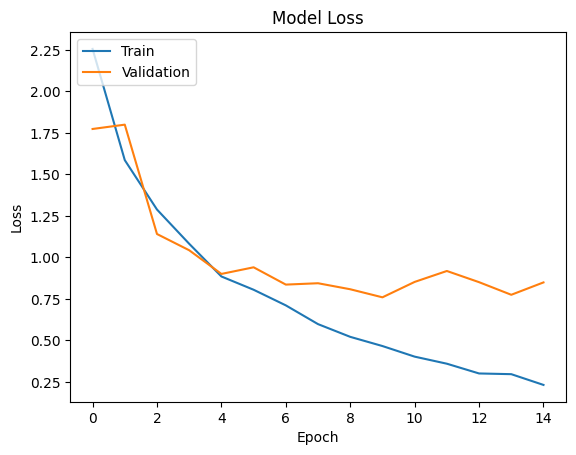

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

model_1 = Sequential()
model_1.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)))
model_1.add(MaxPooling2D((2, 2), padding='same'))
model_1.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D((2, 2), padding='same'))
model_1.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D((2, 2), padding='same'))
# Flatten
model_1.add(Flatten())
model_1.add(Dense(100, activation='relu'))
# Output Layer
model_1.add(Dense(12, activation='softmax'))

# Optimizer
opt = Adam()  # Par défaut lr=0.001

# Compilation
model_1.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
model_1.summary()

# EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_1 = model_1.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.1,
    callbacks=[early_stop]
)


plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# Confusion Matrices and Classification Reports for Train and Test

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


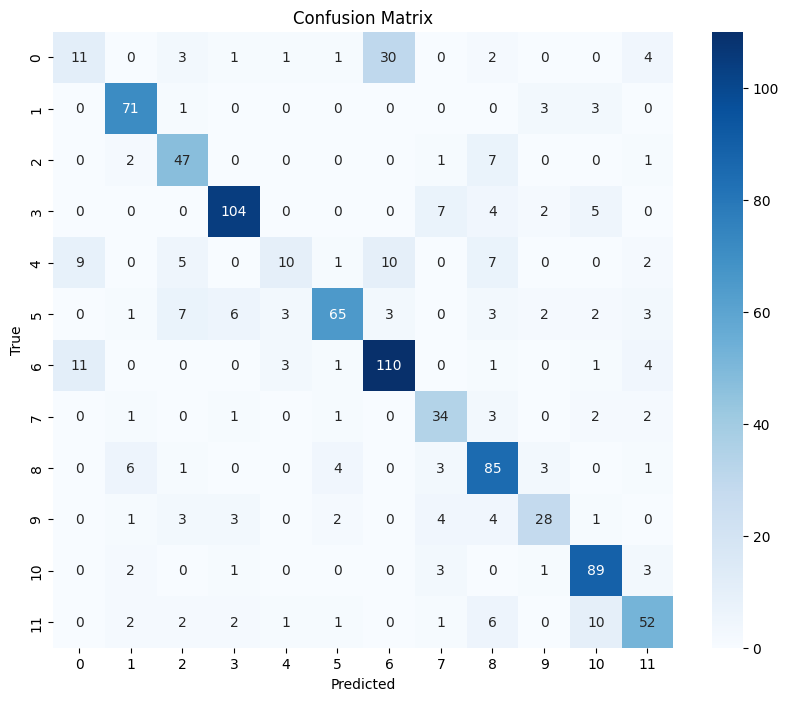

              precision    recall  f1-score   support

           0       0.35      0.21      0.26        53
           1       0.83      0.91      0.87        78
           2       0.68      0.81      0.74        58
           3       0.88      0.85      0.87       122
           4       0.56      0.23      0.32        44
           5       0.86      0.68      0.76        95
           6       0.72      0.84      0.77       131
           7       0.64      0.77      0.70        44
           8       0.70      0.83      0.76       103
           9       0.72      0.61      0.66        46
          10       0.79      0.90      0.84        99
          11       0.72      0.68      0.70        77

    accuracy                           0.74       950
   macro avg       0.70      0.69      0.69       950
weighted avg       0.73      0.74      0.73       950



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions on the test set

y_pred_probs = model_1.predict(X_test) # probabilistic predictions
y_pred = np.argmax(y_pred_probs, axis=1) # convert into labels
y_true = np.argmax(y_test, axis=1)  # real labels (one-hot to int)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: Model 1 Test')
plt.show()

report = classification_report(y_true, y_pred)
print(report)


119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


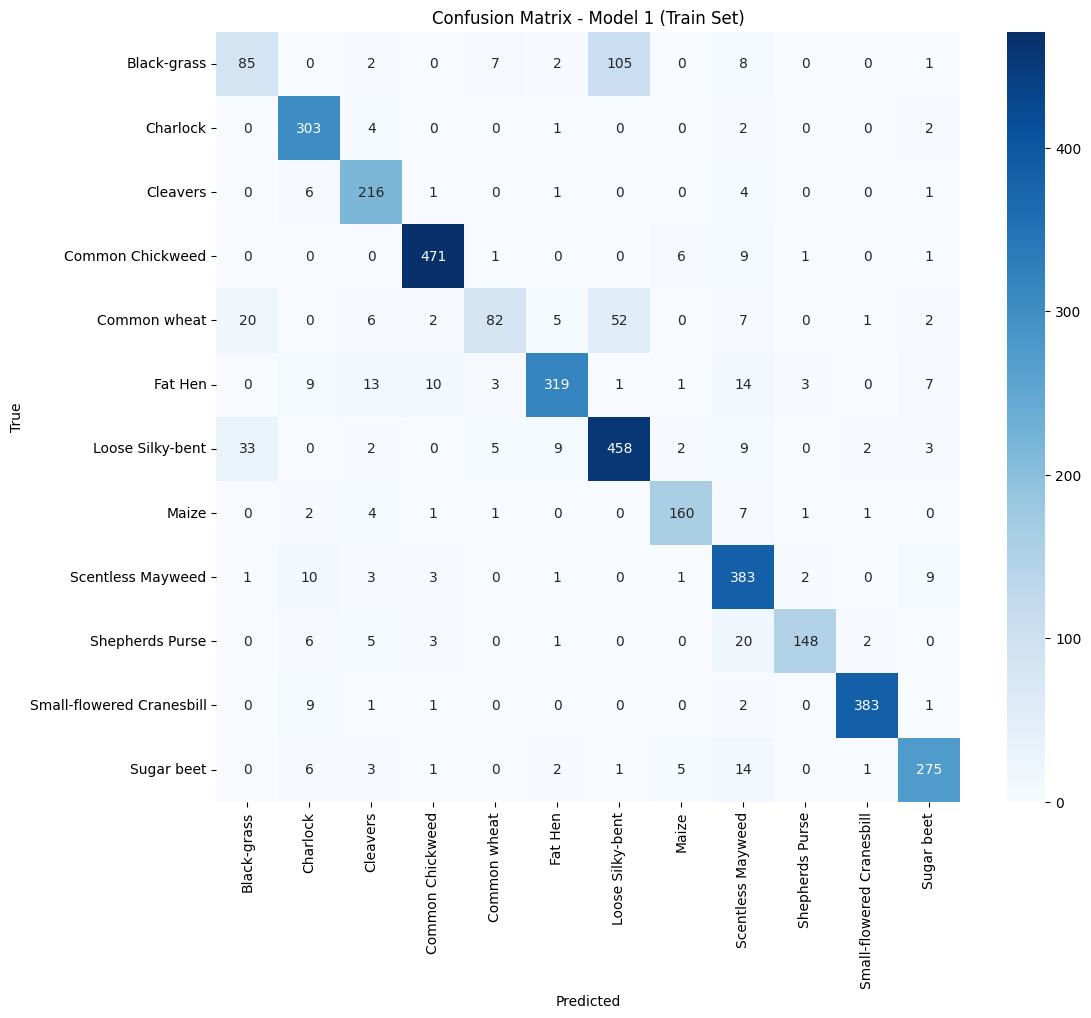

Classification Report - Model 1 (Train Set)
                           precision    recall  f1-score   support

              Black-grass       0.61      0.40      0.49       210
                 Charlock       0.86      0.97      0.91       312
                 Cleavers       0.83      0.94      0.89       229
         Common Chickweed       0.96      0.96      0.96       489
             Common wheat       0.83      0.46      0.59       177
                  Fat Hen       0.94      0.84      0.88       380
         Loose Silky-bent       0.74      0.88      0.80       523
                    Maize       0.91      0.90      0.91       177
        Scentless Mayweed       0.80      0.93      0.86       413
          Shepherds Purse       0.95      0.80      0.87       185
Small-flowered Cranesbill       0.98      0.96      0.97       397
               Sugar beet       0.91      0.89      0.90       308

                 accuracy                           0.86      3800
                

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predictions on the training set
y_pred_probs_train = model_1.predict(X_train)   # probabilistic predictions
y_pred_train = np.argmax(y_pred_probs_train, axis=1)  # convert into labels
y_true_train = np.argmax(y_train, axis=1)       # real labels (one-hot to int)

# Confusion matrix
cm_train = confusion_matrix(y_true_train, y_pred_train)

plt.figure(figsize=(12,10))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: Model 1 (Train Set)')
plt.show()

# Classification report
report_train = classification_report(y_true_train, y_pred_train, target_names=le.classes_)
print("Classification Report: Model 1 (Train Set)")
print(report_train)


# Model 2: Enhanced CNN with Data Augmentation and Regularization

In [ ]:
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization, Dropout, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

# Compute class weights

y_train_labels = np.argmax(y_train, axis=1)

class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

print("Class Weights utilisés :")
print(class_weights)

# Data augmentation

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = datagen.flow(X_train, y_train, subset='training')
val_gen = datagen.flow(X_train, y_train, subset='validation')

# Model 2 architecture

model2 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(12, activation='softmax')
])

model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Training

history2 = model2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[early_stop],
    class_weight=class_weights
)


Class Weights utilisés :
{0: np.float64(1.507936507936508), 1: np.float64(1.014957264957265), 2: np.float64(1.3828238719068413), 3: np.float64(0.6475800954328562), 4: np.float64(1.7890772128060264), 5: np.float64(0.8333333333333334), 6: np.float64(0.6054811982154238), 7: np.float64(1.7890772128060264), 8: np.float64(0.7667473769168685), 9: np.float64(1.7117117117117118), 10: np.float64(0.797649034424853), 11: np.float64(1.0281385281385282)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


95/95 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - accuracy: 0.1965 - loss: 2.9924 - val_accuracy: 0.1171 - val_loss: 10.4177
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.3487 - loss: 1.9271 - val_accuracy: 0.0632 - val_loss: 16.1821
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.3951 - loss: 1.6994 - val_accuracy: 0.0632 - val_loss: 7.1532
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.4355 - loss: 1.5507 - val_accuracy: 0.1197 - val_loss: 4.3404
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.4936 - loss: 1.4242 - val_accuracy: 0.1789 - val_loss: 3.9039
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.5607 - loss: 1.3121 - val_accuracy: 0.2947 - val_loss: 2.4764
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.5776 - loss: 1.2190 - val_accuracy: 0.2882 - val_loss: 3.1819
Epoch 8/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.6039 - loss: 1.1498 - val_accuracy: 0.6132 - val_loss:

# Confusion Matrices and Classification Reports for train and test

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step


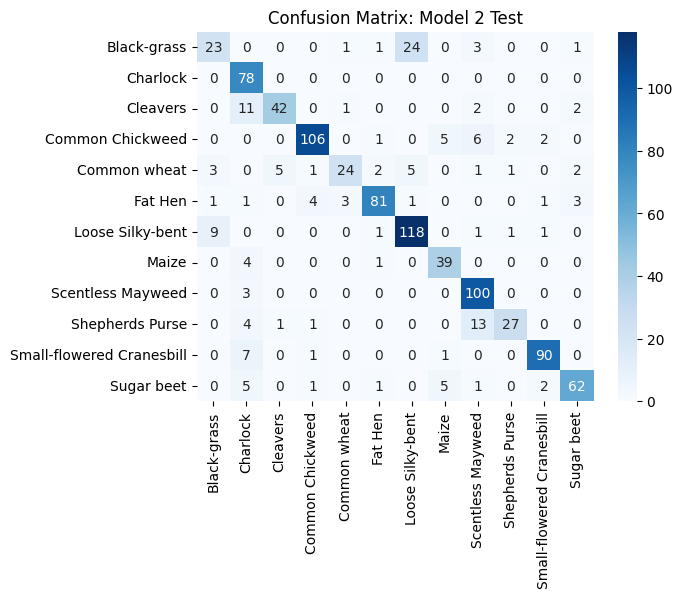

Classification Report: Model 2 Test
                           precision    recall  f1-score   support

              Black-grass       0.64      0.43      0.52        53
                 Charlock       0.69      1.00      0.82        78
                 Cleavers       0.88      0.72      0.79        58
         Common Chickweed       0.93      0.87      0.90       122
             Common wheat       0.83      0.55      0.66        44
                  Fat Hen       0.92      0.85      0.89        95
         Loose Silky-bent       0.80      0.90      0.85       131
                    Maize       0.78      0.89      0.83        44
        Scentless Mayweed       0.79      0.97      0.87       103
          Shepherds Purse       0.87      0.59      0.70        46
Small-flowered Cranesbill       0.94      0.91      0.92        99
               Sugar beet       0.89      0.81      0.84        77

                 accuracy                           0.83       950
                macro av

In [ ]:
y_true2 = np.argmax(y_test, axis=1)
y_pred2 = np.argmax(model2.predict(X_test), axis=1)

cm2 = confusion_matrix(y_true2, y_pred2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix: Model 2 Test")
plt.show()

print("Classification Report: Model 2 Test")
print(classification_report(y_true2, y_pred2, target_names=le.classes_))


119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


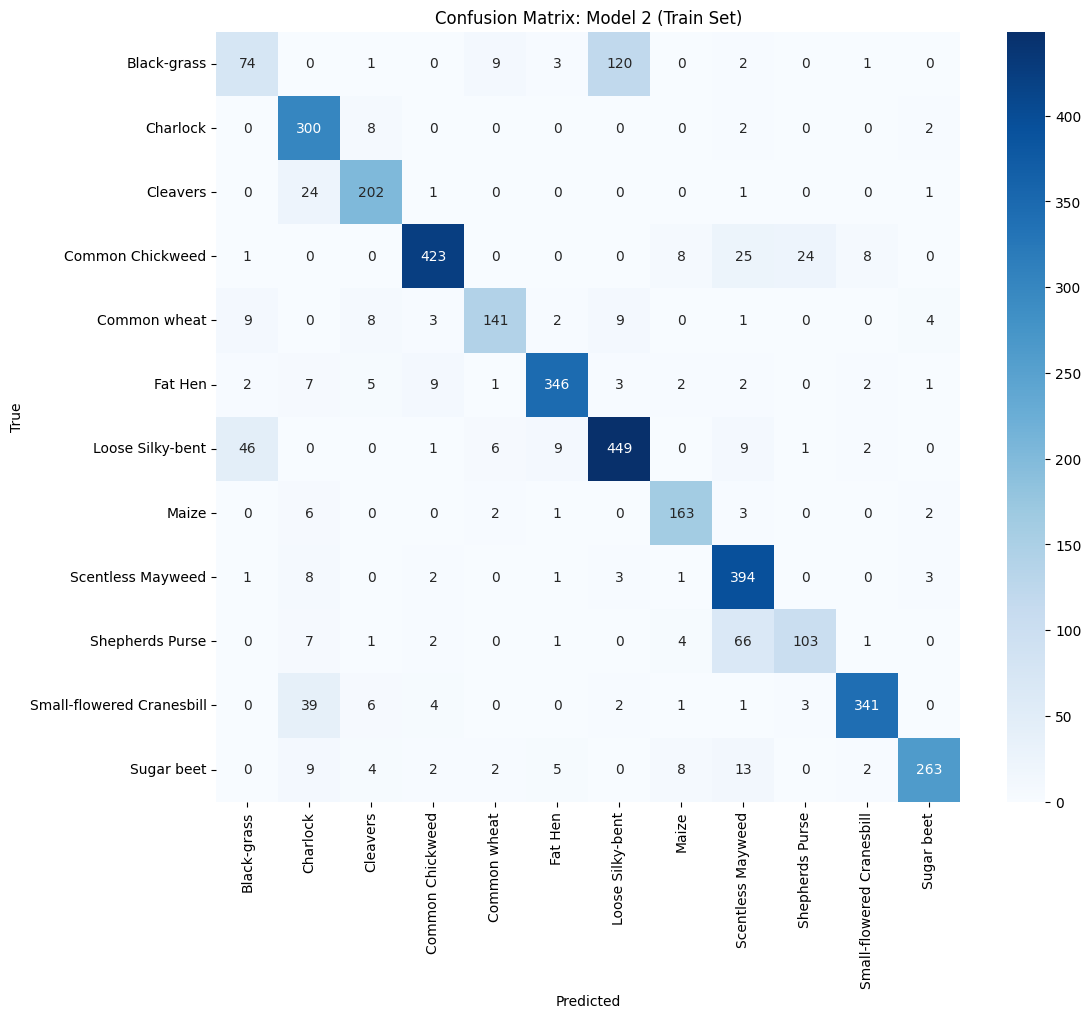

Classification Report: Model 2 (Train Set)
                           precision    recall  f1-score   support

              Black-grass       0.56      0.35      0.43       210
                 Charlock       0.75      0.96      0.84       312
                 Cleavers       0.86      0.88      0.87       229
         Common Chickweed       0.95      0.87      0.90       489
             Common wheat       0.88      0.80      0.83       177
                  Fat Hen       0.94      0.91      0.93       380
         Loose Silky-bent       0.77      0.86      0.81       523
                    Maize       0.87      0.92      0.90       177
        Scentless Mayweed       0.76      0.95      0.85       413
          Shepherds Purse       0.79      0.56      0.65       185
Small-flowered Cranesbill       0.96      0.86      0.90       397
               Sugar beet       0.95      0.85      0.90       308

                 accuracy                           0.84      3800
                m

In [ ]:
y_true_train = np.argmax(y_train, axis=1)
y_pred_train = np.argmax(model2.predict(X_train), axis=1)

# Confusion matrix
cm_train = confusion_matrix(y_true_train, y_pred_train)

plt.figure(figsize=(12,10))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix: Model 2 (Train Set)")
plt.show()

# Classification report
print("Classification Report: Model 2 (Train Set)")
print(classification_report(y_true_train, y_pred_train, target_names=le.classes_))

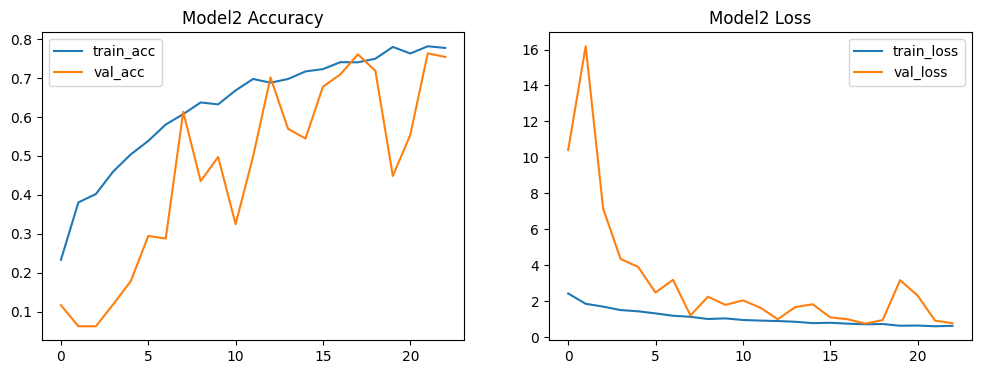

In [ ]:
 #Visualisation
 plt.figure(figsize=(12,4))
 plt.subplot(1,2,1)
 plt.plot(history2.history['accuracy'],label='train_acc')
 plt.plot(history2.history['val_accuracy'],label='val_acc')
 plt.title("Model2 Accuracy")
 plt.legend()
 plt.subplot(1,2,2)
 plt.plot(history2.history['loss'],label='train_loss')
 plt.plot(history2.history['val_loss'],label='val_loss')
 plt.title("Model2 Loss")
 plt.legend()
 plt.show()

# Visualize test samples with their predicted and true labels to see how Model2 perform.

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


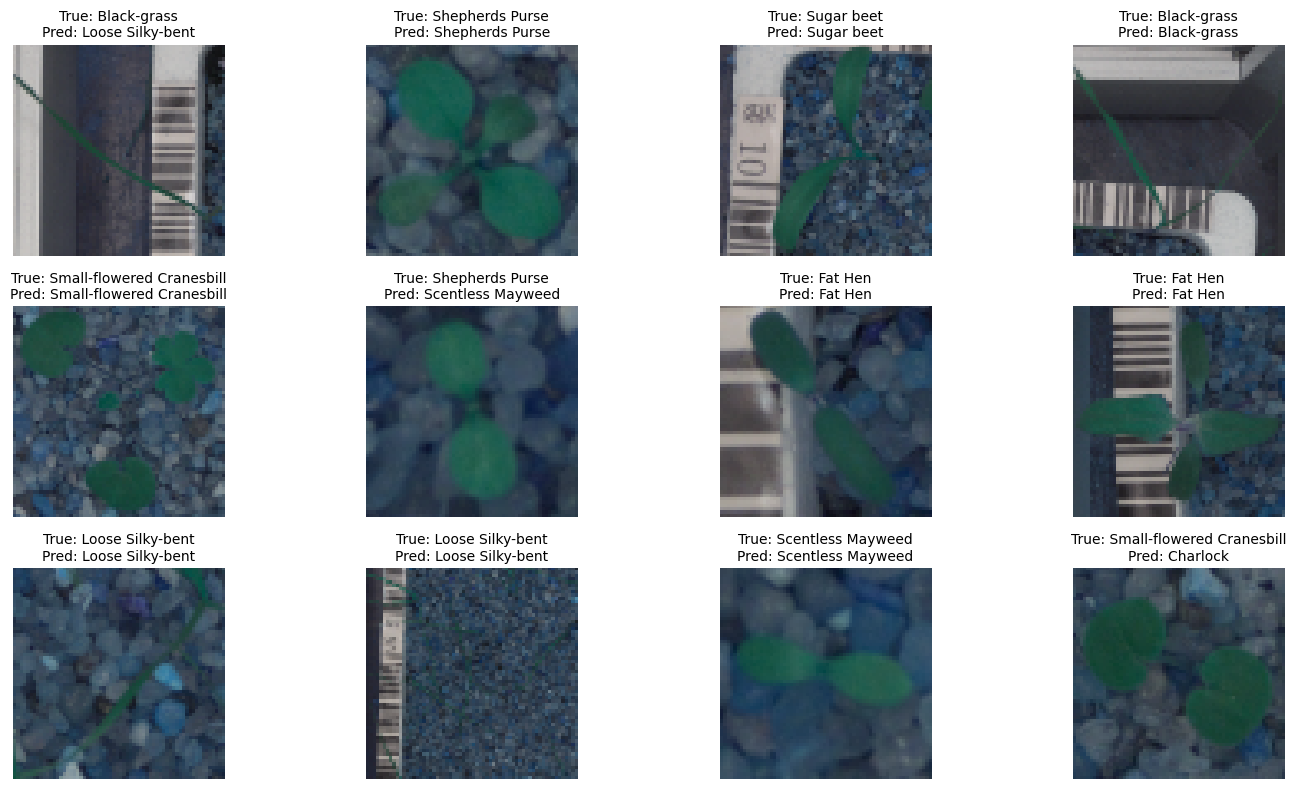

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Predict on the test set
y_pred2 = np.argmax(model2.predict(X_test), axis=1)
y_true2 = np.argmax(y_test, axis=1)

# Number of test samples to display
num_samples = 12
indices = np.random.choice(len(X_test), num_samples, replace=False)

# Plot
plt.figure(figsize=(15,8))
for i, idx in enumerate(indices):
    ax = plt.subplot(3, 4, i+1)
    # Check if image has 3 channels
    if X_test.shape[-1] == 3:
        plt.imshow(X_test[idx])
    else:  # grayscale
        plt.imshow(X_test[idx].reshape(64,64), cmap='gray')
    true_label = le.classes_[y_true2[idx]]
    pred_label = le.classes_[y_pred2[idx]]
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()


# Model 3: Transfer Learning with Pre-trained Models
First: VGG16

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(64,64,3))
base_vgg.trainable = False
x = Flatten()(base_vgg.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(12, activation='softmax')(x)
model3_vgg = Model(inputs=base_vgg.input, outputs=output)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
model3_vgg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history3_vgg = model3_vgg.fit(X_train, y_train, validation_split=0.2, epochs=30, batch_size=32, callbacks=[early_stop])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.1981 - loss: 2.3917 - val_accuracy: 0.3553 - val_loss: 1.8839
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3247 - loss: 1.9412 - val_accuracy: 0.4711 - val_loss: 1.6720
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4059 - loss: 1.7306 - val_accuracy: 0.5105 - val_loss: 1.5375
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4344 - loss: 1.6172 - val_accuracy: 0.5053 - val_loss: 1.4786
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4681 - loss: 1.5363 - val_accuracy: 0.5000 - val_loss: 1.4461
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4957 - loss: 1.4671 - val_accuracy: 0.5276 - val_loss: 1.3551
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4972 - loss: 1.4268 - val_accuracy: 0.5566 - val_loss: 1.3404
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accurac

Confusion Matrices and Classification Reports for Test and Train

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step


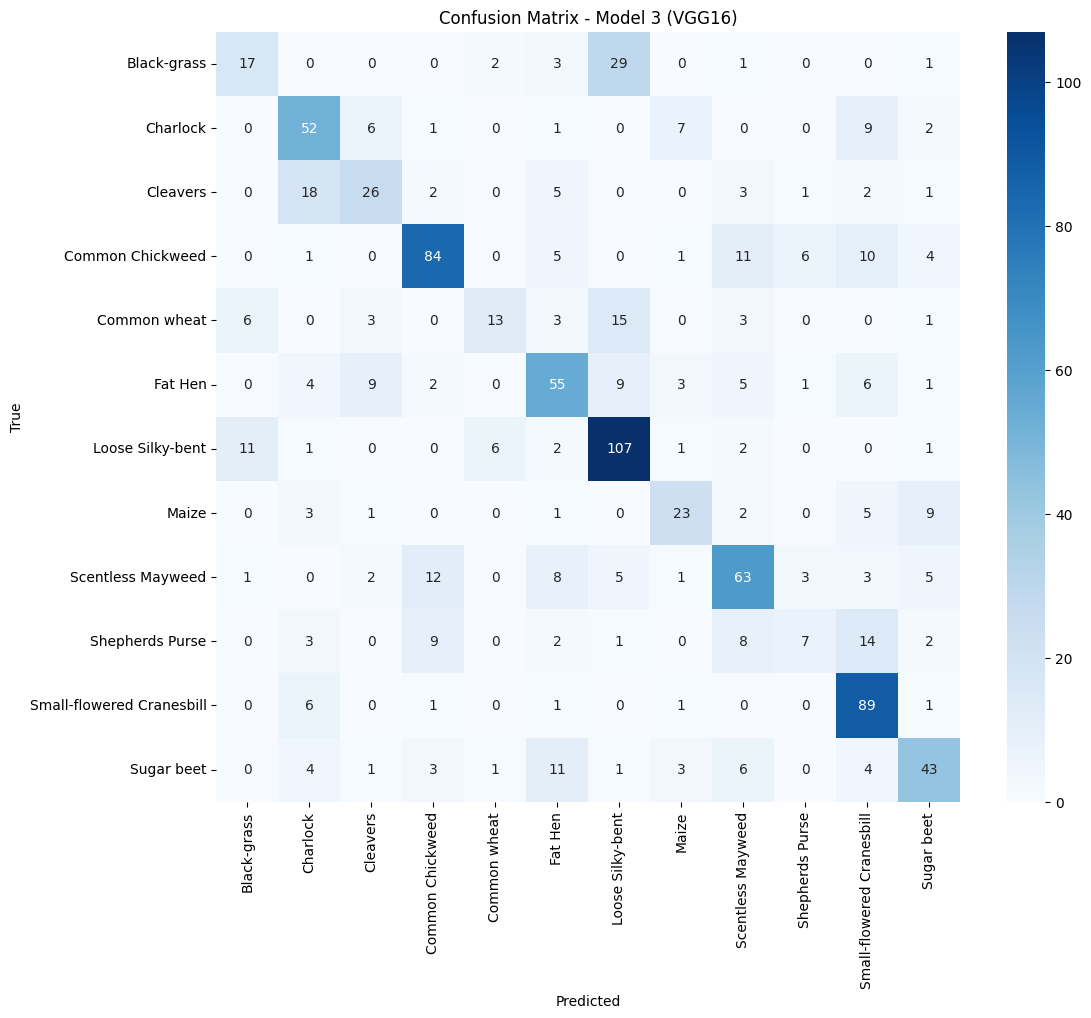

Classification Report - Model 3 (VGG16)
                           precision    recall  f1-score   support

              Black-grass       0.49      0.32      0.39        53
                 Charlock       0.57      0.67      0.61        78
                 Cleavers       0.54      0.45      0.49        58
         Common Chickweed       0.74      0.69      0.71       122
             Common wheat       0.59      0.30      0.39        44
                  Fat Hen       0.57      0.58      0.57        95
         Loose Silky-bent       0.64      0.82      0.72       131
                    Maize       0.57      0.52      0.55        44
        Scentless Mayweed       0.61      0.61      0.61       103
          Shepherds Purse       0.39      0.15      0.22        46
Small-flowered Cranesbill       0.63      0.90      0.74        99
               Sugar beet       0.61      0.56      0.58        77

                 accuracy                           0.61       950
                macr

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions on Test Set
y_pred3 = np.argmax(model3_vgg.predict(X_test), axis=1)
y_true3 = np.argmax(y_test, axis=1)

# Confusion matrix
cm3 = confusion_matrix(y_true3, y_pred3)
plt.figure(figsize=(12,10))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix: Model 3 (VGG16) Test set")
plt.show()

# Classification report
print("Classification Report: Model 3 (VGG16) Test set")
print(classification_report(y_true3, y_pred3, target_names=le.classes_))


119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step


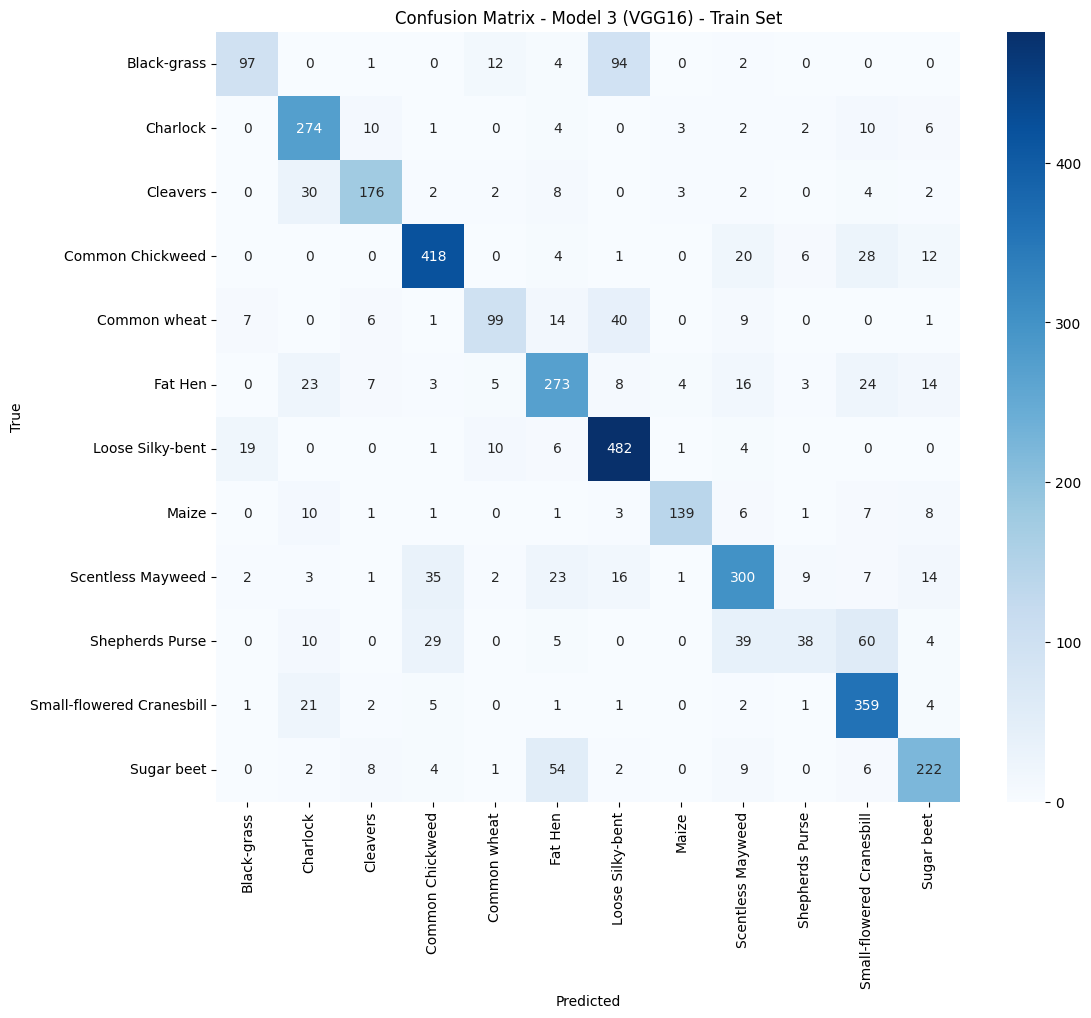

Classification Report - Model 3 (VGG16) - Train Set
                           precision    recall  f1-score   support

              Black-grass       0.77      0.46      0.58       210
                 Charlock       0.73      0.88      0.80       312
                 Cleavers       0.83      0.77      0.80       229
         Common Chickweed       0.84      0.85      0.85       489
             Common wheat       0.76      0.56      0.64       177
                  Fat Hen       0.69      0.72      0.70       380
         Loose Silky-bent       0.74      0.92      0.82       523
                    Maize       0.92      0.79      0.85       177
        Scentless Mayweed       0.73      0.73      0.73       413
          Shepherds Purse       0.63      0.21      0.31       185
Small-flowered Cranesbill       0.71      0.90      0.80       397
               Sugar beet       0.77      0.72      0.75       308

                 accuracy                           0.76      3800
        

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions on Train set
y_pred3_train = np.argmax(model3_vgg.predict(X_train), axis=1)
y_true3_train = np.argmax(y_train, axis=1)

# Confusion matrix
cm3_train = confusion_matrix(y_true3_train, y_pred3_train)

plt.figure(figsize=(12,10))
sns.heatmap(cm3_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix: Model 3 (VGG16) Train Set")
plt.show()

# Classification report
print("Classification Report: Model 3 (VGG16) Train Set")
print(classification_report(y_true3_train, y_pred3_train, target_names=le.classes_))


Confusion Matrices and Classification reports for Train and Test

In [ ]:
!pip install keras-tuner
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from kerastuner import HyperModel
from kerastuner.tuners import RandomSearch

def build_model(hp):
    base_model = tf.keras.applications.VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=(64, 64, 3),
        pooling='avg'
    )
    base_model.trainable = False

    model = keras.Sequential()
    model.add(base_model)

    # --- Hyperparameter tuning for dense layers ---
    units = hp.Int('units', min_value=64, max_value=512, step=64)
    dropout_rate = hp.Float('dropout', min_value=0.2, max_value=0.6, step=0.1)
    model.add(layers.Dense(units, activation='relu'))
    model.add(layers.Dropout(dropout_rate))

    # Output layer
    model.add(layers.Dense(12, activation='softmax'))

    # Optimizer tuning
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

from kerastuner.tuners import RandomSearch

tuner = RandomSearch(
    build_model,
    objective='accuracy',
    max_trials=5,        # nombre de modèles testés
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='vgg16_dnn_tuning'
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(
    X_train, y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop],
    batch_size=32
)

best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(1)[0]

print("Best hyperparameters found:")
print(best_hyperparameters.values)

# Entraîner le meilleur modèle sur tout le train set si nécessaire
history = best_model.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.2,
    batch_size=32
)

Trial 6 Complete [00h 00m 58s]
accuracy: 0.6898026466369629

Best accuracy So Far: 0.6898026466369629
Total elapsed time: 00h 06m 25s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best hyperparameters found:
{'units': 256, 'dropout': 0.30000000000000004, 'learning_rate': 0.001}
Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.7004 - loss: 0.8934 - val_accuracy: 0.6092 - val_loss: 1.1126
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7049 - loss: 0.8611 - val_accuracy: 0.6118 - val_loss: 1.1177
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7241 - loss: 0.8330 - val_accuracy: 0.6224 - val_loss: 1.0951
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7137 - loss: 0.8332 - val_accuracy: 0.6171 - val_loss: 1.1007
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7396 - loss: 0.7776 - val_accuracy: 0.6303 - val_loss: 1.0971
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7316 - loss: 0.7992 - val_accuracy: 0.6474 - val_loss: 1.0776
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7357 - loss: 0.7689 - val_accuracy: 0.6250 - val_loss: 1.0905
Epoch 8/20
9

119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step


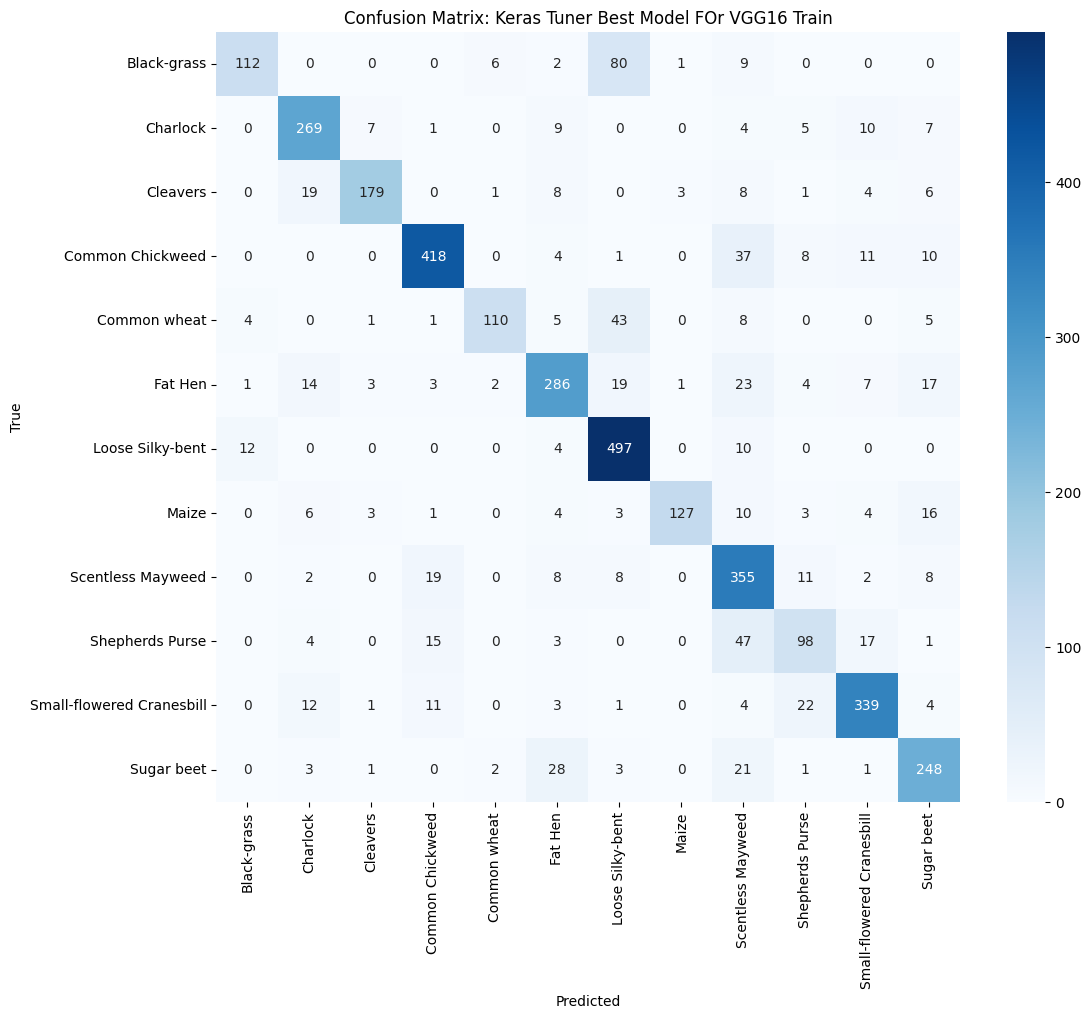


Classification Report: Train
                           precision    recall  f1-score   support

              Black-grass       0.87      0.53      0.66       210
                 Charlock       0.82      0.86      0.84       312
                 Cleavers       0.92      0.78      0.84       229
         Common Chickweed       0.89      0.85      0.87       489
             Common wheat       0.91      0.62      0.74       177
                  Fat Hen       0.79      0.75      0.77       380
         Loose Silky-bent       0.76      0.95      0.84       523
                    Maize       0.96      0.72      0.82       177
        Scentless Mayweed       0.66      0.86      0.75       413
          Shepherds Purse       0.64      0.53      0.58       185
Small-flowered Cranesbill       0.86      0.85      0.86       397
               Sugar beet       0.77      0.81      0.79       308

                 accuracy                           0.80      3800
                macro avg     

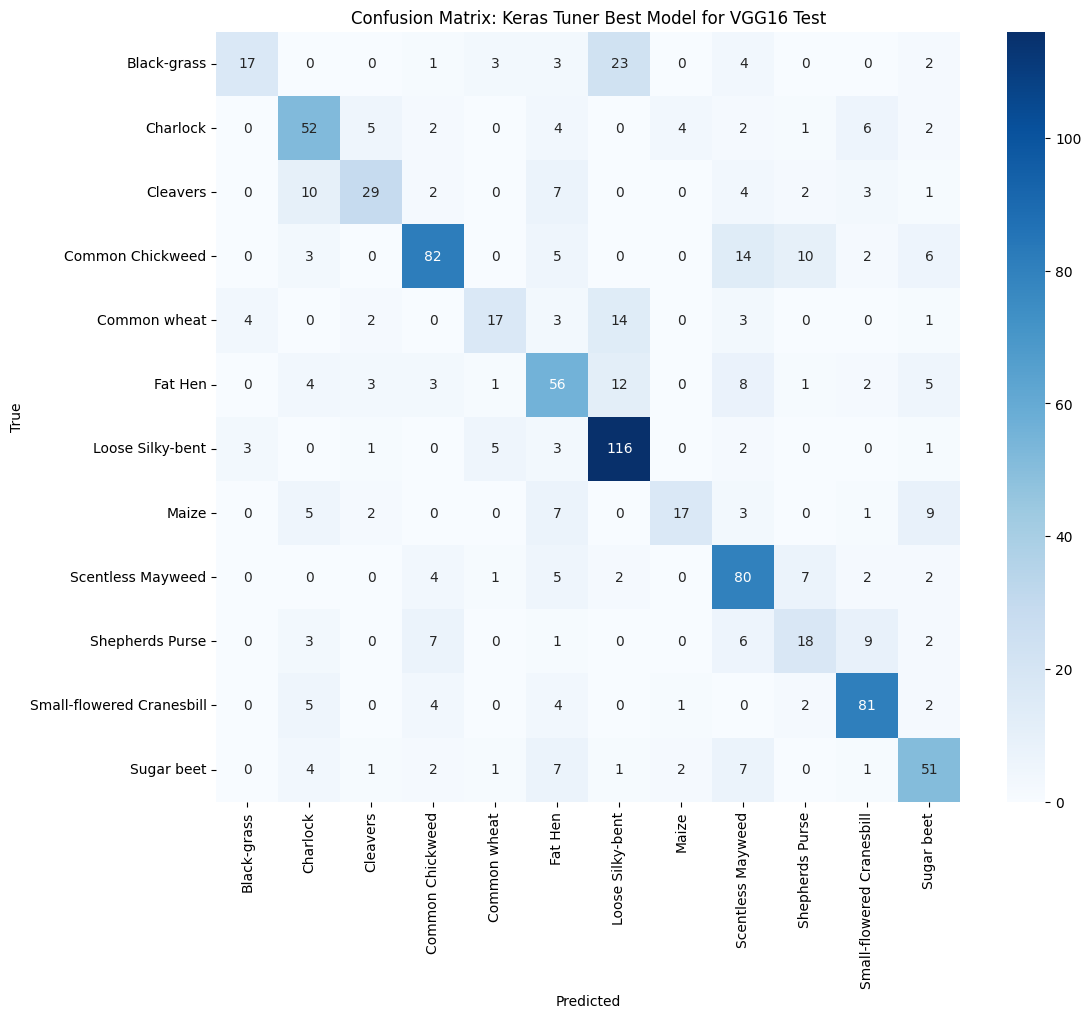


Classification Report: Test
                           precision    recall  f1-score   support

              Black-grass       0.71      0.32      0.44        53
                 Charlock       0.60      0.67      0.63        78
                 Cleavers       0.67      0.50      0.57        58
         Common Chickweed       0.77      0.67      0.72       122
             Common wheat       0.61      0.39      0.47        44
                  Fat Hen       0.53      0.59      0.56        95
         Loose Silky-bent       0.69      0.89      0.78       131
                    Maize       0.71      0.39      0.50        44
        Scentless Mayweed       0.60      0.78      0.68       103
          Shepherds Purse       0.44      0.39      0.41        46
Small-flowered Cranesbill       0.76      0.82      0.79        99
               Sugar beet       0.61      0.66      0.63        77

                 accuracy                           0.65       950
                macro avg      

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Confusion Matrix for Train
y_pred_train = np.argmax(best_model.predict(X_train), axis=1)
y_true_train = np.argmax(y_train, axis=1)

cm_train = confusion_matrix(y_true_train, y_pred_train)

plt.figure(figsize=(12,10))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix: Keras Tuner Best Model FOr VGG16 Train")
plt.show()

print("\nClassification Report: Train")
print(classification_report(y_true_train, y_pred_train, target_names=le.classes_))


# Confusion Matrix for Test

y_pred_test = np.argmax(best_model.predict(X_test), axis=1)
y_true_test = np.argmax(y_test, axis=1)

cm_test = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(12,10))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix: Keras Tuner Best Model for VGG16 Test")
plt.show()

print("\nClassification Report: Test")
print(classification_report(y_true_test, y_pred_test, target_names=le.classes_))


# VGG19

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

base_vgg19 = VGG19(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
base_vgg19.trainable = False
x = Flatten()(base_vgg19.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(12, activation='softmax')(x)
model3_vgg19 = Model(inputs=base_vgg19.input, outputs=output)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Compile model
model3_vgg19.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history3_vgg19 = model3_vgg19.fit(X_train, y_train, validation_split=0.2, epochs=30, batch_size=32, callbacks=[early_stop])

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.2087 - loss: 2.3307 - val_accuracy: 0.3382 - val_loss: 1.9096
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3354 - loss: 1.9057 - val_accuracy: 0.4289 - val_loss: 1.6963
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3787 - loss: 1.7765 - val_accuracy: 0.4461 - val_loss: 1.6370
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4290 - loss: 1.6856 - val_accuracy: 0.4632 - val_loss: 1.4956
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4542 - loss: 1.6008 - val_accuracy: 0.4855 - val_loss: 1.4444
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4778 - loss: 1.5069 - val_accuracy: 0.4974 - val_loss: 1.4213
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4660 - loss: 1.5003 - val_accuracy: 0.4974 - val_loss: 1.3838
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accurac

Confusion Matrices and Classification Reports for Test and Train

119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step


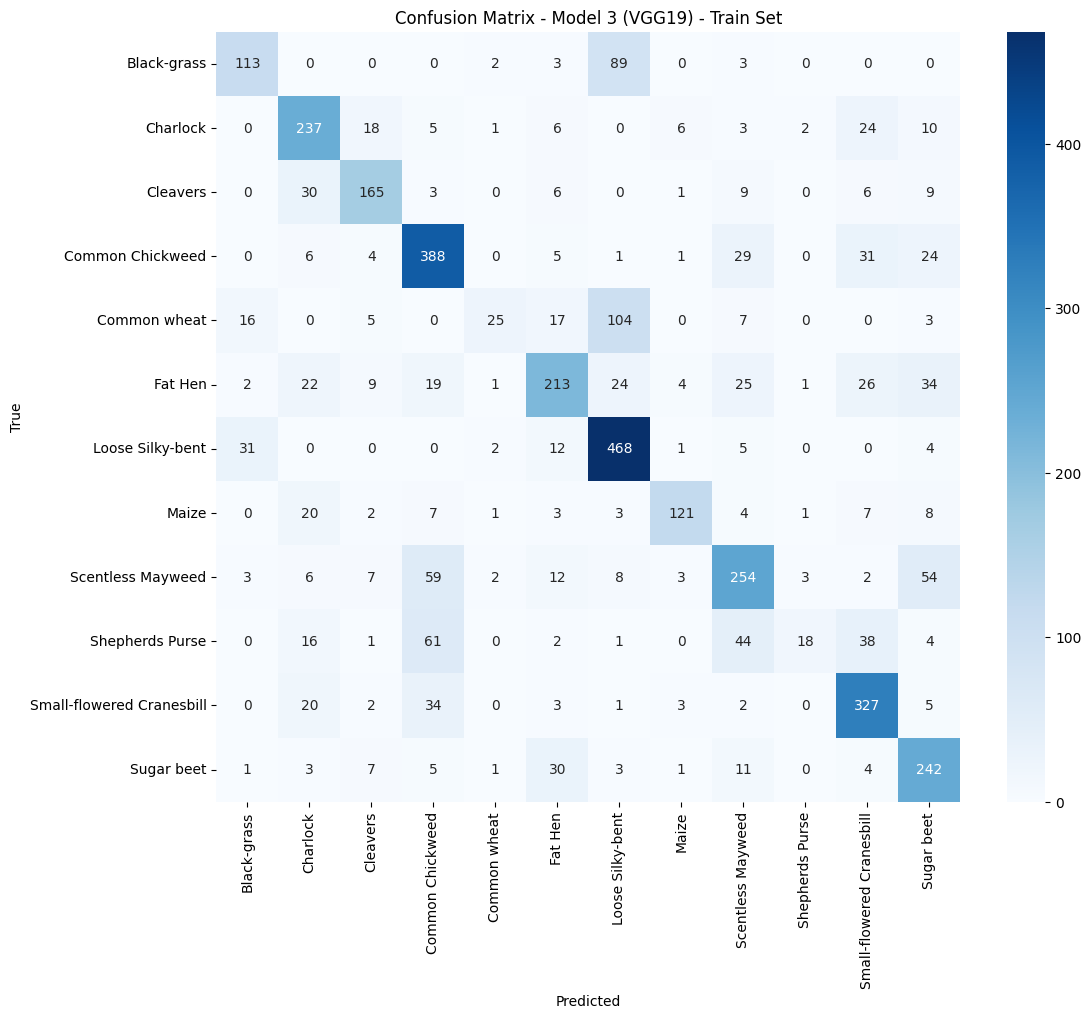

Classification Report - Model 3 (VGG19) - Train Set
                           precision    recall  f1-score   support

              Black-grass       0.68      0.54      0.60       210
                 Charlock       0.66      0.76      0.71       312
                 Cleavers       0.75      0.72      0.73       229
         Common Chickweed       0.67      0.79      0.73       489
             Common wheat       0.71      0.14      0.24       177
                  Fat Hen       0.68      0.56      0.62       380
         Loose Silky-bent       0.67      0.89      0.76       523
                    Maize       0.86      0.68      0.76       177
        Scentless Mayweed       0.64      0.62      0.63       413
          Shepherds Purse       0.72      0.10      0.17       185
Small-flowered Cranesbill       0.70      0.82      0.76       397
               Sugar beet       0.61      0.79      0.69       308

                 accuracy                           0.68      3800
        

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions on Train set
y_pred3_train = np.argmax(model3_vgg19.predict(X_train), axis=1)
y_true3_train = np.argmax(y_train, axis=1)

# Confusion matrix
cm3_train = confusion_matrix(y_true3_train, y_pred3_train)

plt.figure(figsize=(12,10))
sns.heatmap(cm3_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix: Model 3 (VGG19) Train Set")
plt.show()

# Classification report
print("Classification Report: Model 3 (VGG19) Train Set")
print(classification_report(y_true3_train, y_pred3_train, target_names=le.classes_))


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


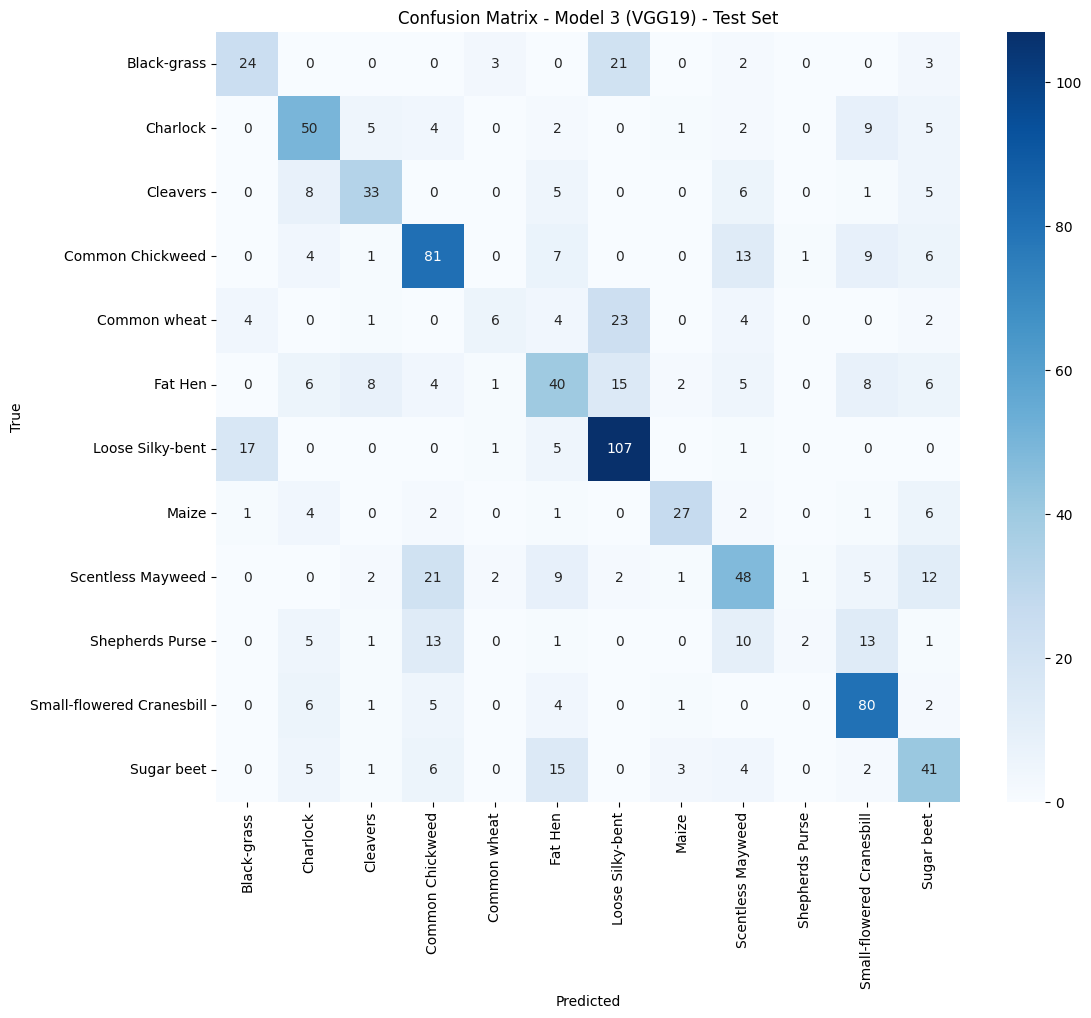

Classification Report - Model 3 (VGG19) - Test Set
                           precision    recall  f1-score   support

              Black-grass       0.52      0.45      0.48        53
                 Charlock       0.57      0.64      0.60        78
                 Cleavers       0.62      0.57      0.59        58
         Common Chickweed       0.60      0.66      0.63       122
             Common wheat       0.46      0.14      0.21        44
                  Fat Hen       0.43      0.42      0.43        95
         Loose Silky-bent       0.64      0.82      0.72       131
                    Maize       0.77      0.61      0.68        44
        Scentless Mayweed       0.49      0.47      0.48       103
          Shepherds Purse       0.50      0.04      0.08        46
Small-flowered Cranesbill       0.62      0.81      0.70        99
               Sugar beet       0.46      0.53      0.49        77

                 accuracy                           0.57       950
         

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions on Test set
y_pred3_test = np.argmax(model3_vgg19.predict(X_test), axis=1)
y_true3_test = np.argmax(y_test, axis=1)

# Confusion matrix
cm3_test = confusion_matrix(y_true3_test, y_pred3_test)

plt.figure(figsize=(12,10))
sns.heatmap(cm3_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix: Model 3 (VGG19) Test Set")
plt.show()

# Classification report
print("Classification Report: Model 3 (VGG19) Test Set")
print(classification_report(y_true3_test, y_pred3_test, target_names=le.classes_))


 # Model Comparison and F1 Score Analysis

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


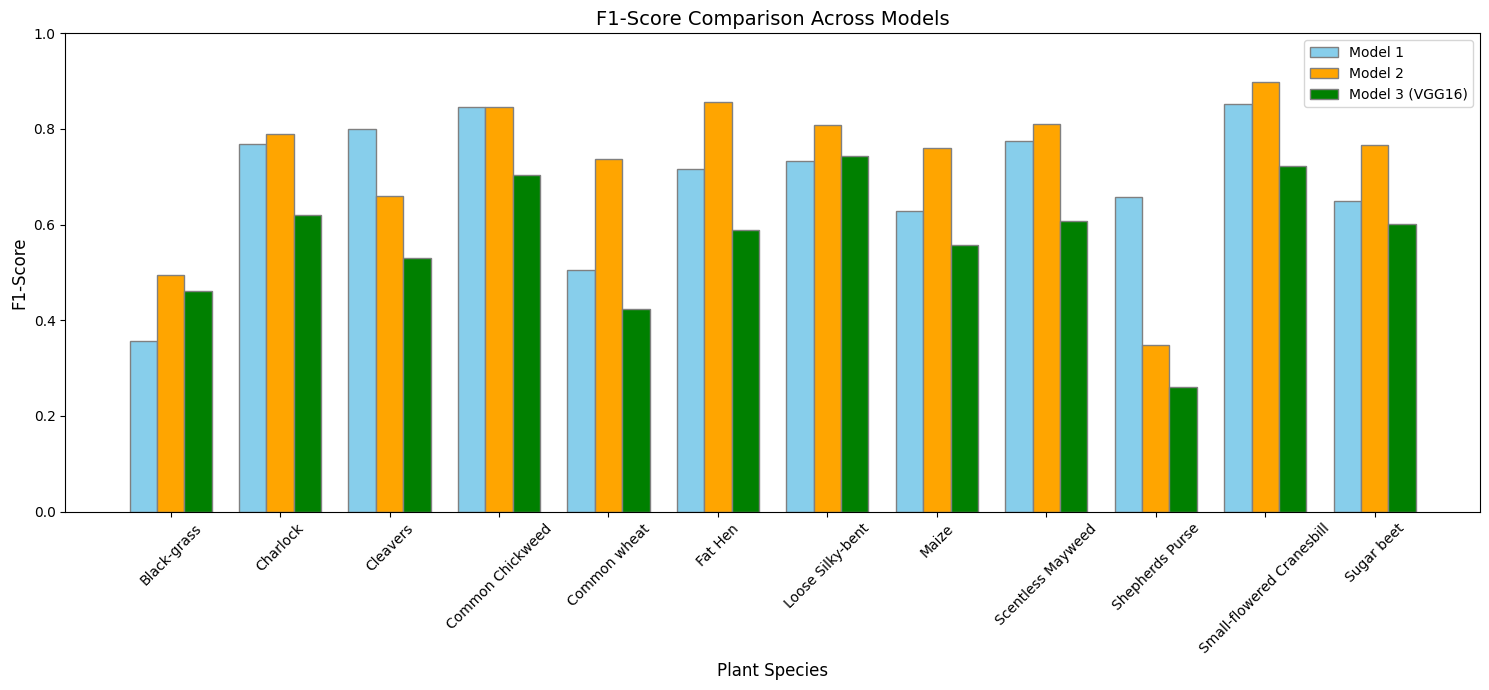

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Model 1
y_true1 = np.argmax(y_test, axis=1)
y_pred1 = np.argmax(model_1.predict(X_test), axis=1)
report1 = classification_report(y_true1, y_pred1, target_names=le.classes_, output_dict=True)
f1_model1 = [report1[cls]['f1-score'] for cls in le.classes_]

# Model 2
y_pred2 = np.argmax(model2.predict(X_test), axis=1)
report2 = classification_report(y_true1, y_pred2, target_names=le.classes_, output_dict=True)
f1_model2 = [report2[cls]['f1-score'] for cls in le.classes_]

# Model 3 (VGG16)
y_pred3 = np.argmax(model3_vgg.predict(X_test), axis=1)  # X_test_rgb = 3 channels for VGG16
report3 = classification_report(y_true1, y_pred3, target_names=le.classes_, output_dict=True)
f1_model3 = [report3[cls]['f1-score'] for cls in le.classes_]

#Creation of a dataframe
df_f1 = pd.DataFrame({
    'Class': le.classes_,
    'Model 1': f1_model1,
    'Model 2': f1_model2,
    'Model 3 (VGG16)': f1_model3
})

# Plot bar chart
plt.figure(figsize=(15,7))
bar_width = 0.25
r1 = range(len(df_f1))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width*2 for x in r1]

plt.bar(r1, df_f1['Model 1'], color='skyblue', width=bar_width, edgecolor='grey', label='Model 1')
plt.bar(r2, df_f1['Model 2'], color='orange', width=bar_width, edgecolor='grey', label='Model 2')
plt.bar(r3, df_f1['Model 3 (VGG16)'], color='green', width=bar_width, edgecolor='grey', label='Model 3 (VGG16)')

plt.xlabel('Plant Species', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('F1-Score Comparison Across Models', fontsize=14)
plt.xticks([r + bar_width for r in range(len(df_f1))], df_f1['Class'], rotation=45)
plt.ylim(0,1)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
!pip install nbconvert

In [ ]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [ ]:
!jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/Louis_Keller_Assignment2.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Louis_Keller_Assignment2.ipynb to pdf
[NbConvertApp] Support files will be in Louis_Keller_Assignment2_files/
[NbConvertApp] Making directory ./Louis_Keller_Assignment2_files
[NbConvertApp] Writing 186447 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1647589 bytes to /content/drive/MyDrive/Colab Notebooks/Louis_Keller_Assignment2.pdf


In [ ]:
!jupyter nbconvert --to pdf --output Louis_Keller_Assignment2.pdf Louis_Keller_Assignment2.ipynb

[NbConvertApp] WARNING | pattern 'Louis_Keller_Assignment2.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
